# Avances y próximos pasos — tras la sesión del 9 de julio

La sesión reorientó el trabajo hacia un paper concreto y cercano. La pieza
central es un ejemplo de **separación**: una familia mínima donde una
estrategia dinámica con pruebas aumentadas supera de forma cerrada al mejor
esquema estático sin aumentar. Alrededor quedan cuatro frentes: un algoritmo
eficiente sobre los regímenes tratables, el modelo realista de pruebas, la
verificación de la fibra, y el encuadre de publicación.

Este cuaderno regenera cada número; nada está escrito a mano.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

# --- el ejemplo de separación, en dos funciones ---
def util_estatico(B, q):
    '''Óptimo estático (individual) sobre u: B*q.'''
    return B * q

def util_dinamico(B, G, q):
    '''Cota inferior del dinámico aumentado sobre u: 1-(1-q)^(kG),
    con kG=(B-log2 G)*G. Devuelve (valor, kG) o (None, None) si B<1+log2 G.'''
    logG = math.log2(G)
    if abs(logG - round(logG)) > 1e-9:
        raise ValueError('G debe ser potencia de 2')
    logG = round(logG)
    k = B - logG
    if k < 1:
        return None, None
    kG = k * G
    return 1.0 - (1.0 - q) ** kG, kG

print('funciones listas')

funciones listas


## 1. El ejemplo de separación

**El montaje.** Población infinita y homogénea: cada persona tiene utilidad
$u$ y probabilidad $q$ de estar sana (infectada con probabilidad $1-q$).
Pruebas de grupo de tamaño $G$; presupuesto $B = k + \log_2 G$; y $q < 1/2$
(prevalencia alta). Se acredita $u$ a quien queda *probado sano*, es decir, en
un pool cuyo conteo de infectados es cero.

La pregunta que ancla el paper: ¿cuándo un esquema **dinámico con conteo**
supera al mejor esquema **estático sin conteo**? Este ejemplo lo exhibe en
forma cerrada.

**Óptimo estático.** El recurso escaso es el número de pruebas, no la gente,
así que la métrica correcta es utilidad esperada por prueba. Una prueba
individual acredita $u$ con probabilidad $q$: rinde $u\,q$. Una prueba de
grupo de tamaño $g$ acredita a sus $g$ miembros solo si todos están sanos
(probabilidad $q^g$): rinde $u\,g\,q^g$. Individual domina cuando
$g\,q^{g-1}\le 1$, y para $q<1/2$, $g\ge 2$ eso se cumple siempre
($g/2^{g-1}\le 1$). El valor óptimo estático es entonces

$$U^{\text{est}} = B\,u\,q.$$

(El argumento cubre también diseños estáticos con solape, por cota de unión:
$\sum_i P(i \text{ acreditado}) \le \sum_t |t|\,q^{|t|} \le B\,q$, usando la
misma desigualdad $g\,q^{g}\le q$ por prueba.)

**Dinámico aumentado.** Con el presupuesto $B=k+\log_2 G$ se hacen $k$ pruebas
sobre $k$ grupos disjuntos de $G$ personas — cubren $kG$ en total —, y si un
grupo reporta al menos un sano, se aísla con una búsqueda binaria de conteo en
$\log_2 G$ pruebas (invariante: un bloque cuyo conteo de infectados es menor
que su tamaño contiene al menos un sano). Cuando hay algún sano entre las $kG$
personas, la búsqueda garantiza acreditar al menos a uno — y a veces a más: un
bloque testeado con conteo cero acredita a todos sus miembros. La utilidad del
esquema es entonces al menos

$$U^{\text{din}} \ge u\,\bigl(1-(1-q)^{kG}\bigr), \qquad kG=(B-\log_2 G)\,G,$$

cota inferior del óptimo dinámico (que además puede certificar gratis a los
$G$ miembros de un grupo inicial con conteo cero).

Un detalle de contabilidad, verificado por enumeración: si acreditar exige
literalmente pertenecer a un pool testeado con conteo cero, el último paso de
la búsqueda puede identificar al sano por descarte sin haberlo testeado
(ocurre en $\sim 1/3$ de los patrones con $G=16$) y acreditarlo cuesta una
prueba extra. Basta tomar $B = k + \log_2 G + 1$, o la convención natural de
que quedar probado sano por deducción también acredita. Nada cualitativo
cambia.

In [2]:
# instancia ancla: prevalencia alta (q=0.1), grupos de 16, presupuesto 6
q, G, B = 0.1, 16, 6
est = util_estatico(B, q)
din, kG = util_dinamico(B, G, q)
print(f'q={q}  G={G}  B={B}  (k={B-round(math.log2(G))}, cubre kG={kG} personas)')
print(f'  estático  U/u = B*q          = {est:.3f}')
print(f'  dinámico  U/u = 1-(1-q)^kG   = {din:.3f}')
print(f'  ventaja del dinámico: {din-est:+.3f}u  ({100*(din/est-1):+.0f}%)')

q=0.1  G=16  B=6  (k=2, cubre kG=32 personas)
  estático  U/u = B*q          = 0.600
  dinámico  U/u = 1-(1-q)^kG   = 0.966
  ventaja del dinámico: +0.366u  (+61%)


**La separación, y un matiz sobre el exponente.** El dinámico supera al
estático cuando $1-(1-q)^{kG} > B\,q$. Francisco escribió la cobertura como
$kG\approx B$; la cobertura real es $kG=(B-\log_2 G)\,G\approx B\,G$, un factor
$\sim G$ mayor. El matiz importa, y en la dirección correcta: por la
desigualdad de Bernoulli, $1-(1-q)^{n}\le n\,q$, así que si la cobertura fuera
solo $B$ el dinámico **nunca** ganaría. Con la cobertura verdadera gana con
holgura. Corregir el exponente refuerza la tesis, no la debilita.

In [3]:
# Bernoulli: con exponente B el dinámico jamás ganaría (1-(1-q)^B <= B*q)
qs = np.linspace(0.02, 0.48, 25); Bs = np.arange(2, 15)
peor = max(float((1-(1-q)**b) - b*q) for q in qs for b in Bs)
print(f'max sobre la rejilla de (1-(1-q)^B) - B*q = {peor:.4f}   (<=0 => con kG~B nunca gana)')
print('con el exponente REAL kG=(B-log2 G)*G, en cambio, la separación sí ocurre (abajo)')

max sobre la rejilla de (1-(1-q)^B) - B*q = -0.0004   (<=0 => con kG~B nunca gana)
con el exponente REAL kG=(B-log2 G)*G, en cambio, la separación sí ocurre (abajo)


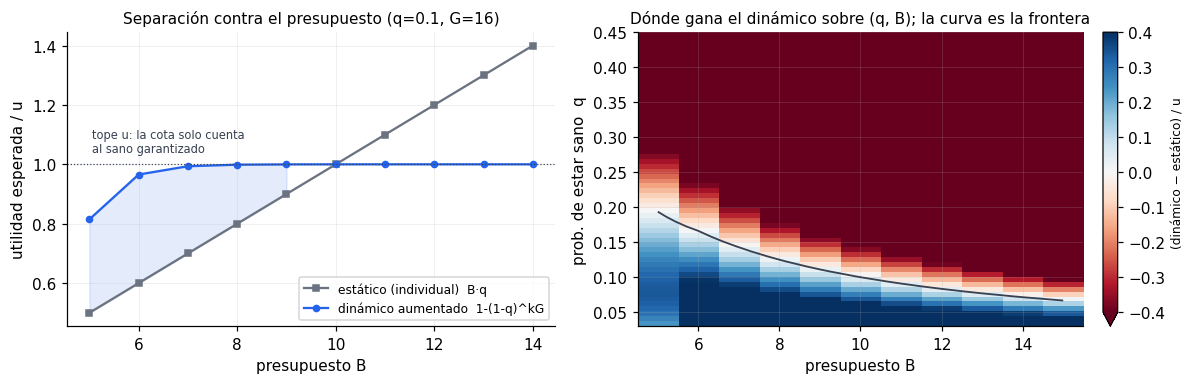

In [4]:
# figura: estático vs dinámico contra el presupuesto B (q=0.1, G=16)
q, G = 0.1, 16
Bs = list(range(1 + round(math.log2(G)), 15))
est = [util_estatico(b, q) for b in Bs]
din = [util_dinamico(b, G, q)[0] for b in Bs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

ax1.plot(Bs, est, marker='s', ms=4, color=GRIS, label='estático (individual)  B·q')
ax1.plot(Bs, din, marker='o', ms=4, color=AZUL, label='dinámico aumentado  1-(1-q)^kG')
ax1.fill_between(Bs, est, din, where=[d > e for e, d in zip(est, din)],
                 color=AZUL, alpha=0.12)
ax1.axhline(1.0, color=TINTA, ls=':', lw=0.8)
ax1.annotate('tope u: la cota solo cuenta\nal sano garantizado',
             (Bs[0], 1.0), textcoords='offset points', xytext=(2, 6),
             ha='left', va='bottom', fontsize=7.5, color=TINTA)
ax1.set_xlabel('presupuesto B'); ax1.set_ylabel('utilidad esperada / u')
ax1.set_title(f'Separación contra el presupuesto (q={q}, G={G})', fontsize=10)
ax1.legend(fontsize=8, loc='lower right')

# heatmap: región donde gana el dinámico, sobre (q, B) para G=16.
# La escala se recorta a +-0.4 (la magnitud de las victorias) para que la
# región de victoria no la aplasten las derrotas grandes de q alto; la
# frontera din=est se marca con una curva de nivel.
qs = np.linspace(0.03, 0.45, 60); Bgrid = np.arange(1 + round(math.log2(G)), 16)
adv = np.full((len(qs), len(Bgrid)), np.nan)
for i, qq in enumerate(qs):
    for j, bb in enumerate(Bgrid):
        d, _ = util_dinamico(int(bb), G, qq)
        if d is not None:
            adv[i, j] = d - util_estatico(int(bb), qq)
im = ax2.imshow(adv, origin='lower', aspect='auto', cmap='RdBu',
                vmin=-0.4, vmax=0.4,
                extent=[Bgrid[0]-.5, Bgrid[-1]+.5, qs[0], qs[-1]])
BB, QQ = np.meshgrid(Bgrid, qs)
ax2.contour(BB, QQ, adv, levels=[0.0], colors=[TINTA], linewidths=1.2)
ax2.set_xlabel('presupuesto B'); ax2.set_ylabel('prob. de estar sano  q')
ax2.set_title('Dónde gana el dinámico sobre (q, B); la curva es la frontera',
              fontsize=10)
cb = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, extend='min')
cb.set_label('(dinámico − estático) / u', fontsize=8)
fig.tight_layout(); plt.show()

Dos lecturas. La separación es fuerte con **prevalencia alta** ($q$
pequeño) y **presupuesto moderado**: ahí encontrar a un sano raro es caro
individualmente —el estático rinde solo $B\,q$—, pero barato con conteo, que
permite hacer búsqueda binaria de la aguja en el pajar. Y hay un cruce honesto:
la cota solo cuenta al sano garantizado, así que topa en $u$, mientras el
estático crece lineal; para $B\gtrsim 1/q$ el estático rebasa a la cota.
La ventana de victoria es $1+\log_2 G \le B < 1/q$.

Refinamiento (para el apéndice): eligiendo $G$ óptimo la cobertura llega a
$kG^\ast = 2^{B-1}$, de modo que la condición canónica de separación es
$B\,q < 1-(1-q)^{2^{B-1}}$ — cobertura exponencial en el presupuesto.

**Estado:** este ejemplo, solo, ya es un resultado del paper. Francisco envía
el resultado del extremo estático; aquí queda la instancia y la verificación.

## 2. Los regímenes tratables y un algoritmo eficiente

El segundo frente: los regímenes donde la inferencia exacta —que en general es
#P-hard— se vuelve tratable. Dos familias, ambas por la misma razón: el
posterior factoriza cuando la estructura de traslape es simple. Abajo se
construye cada una en chiquito, se verifica contra la fuerza bruta, y se escala
a tamaños donde la fuerza bruta es físicamente imposible.

**Laminar: cajas dentro de cajas.** Pools anidados (cada par es disjunto o uno
contiene al otro). La gracia: los conteos anidados se *restan*. Si el pool
grande $A$ reporta 5 infectados y su sub-pool $B$ reporta 2, entonces la capa
$A\setminus B$ tiene exactamente $5-2=3$. Con todos los niveles testeados, cada
capa queda con su conteo fijado y el problema se rompe en subproblemas
independientes del tipo "exactamente $k$ infectados entre $m$ personas" — que
se resuelve exacto con polinomios simétricos en $O(m\cdot k)$, sin enumerar
$2^m$. (Si solo algunos niveles están testeados, la resta deja de fijar y se
convierte en un DP sobre el árbol laminar; misma idea, un paso más.)

In [5]:
from augmented.core import mask_from_indices
from augmented.bayesian import bayesian_update_by_counting
import time

def marginales_k_de_m(ps, k):
    '''P(Z_i=1 | exactamente k infectados entre estas m personas), exacto en
    O(m*k) via polinomios simetricos elementales (forward-backward) sobre las
    ODDS r_i = p_i/q_i. Trabajar en odds cancela el factor comun prod(q) y
    evita el underflow que mataria los pesos crudos con m grande
    (0.5^2000 ~ 1e-602 no cabe en un float; las esym de odds con k chico si).
    Formula: P(Z_i=1 | k de m) = r_i * e_{k-1}(r_(-i)) / e_k(r).'''
    m = len(ps)
    odds = [pi / (1.0 - pi) for pi in ps]
    F = [[1.0]]                      # F[i][j] = e_j(odds de los primeros i)
    for i in range(m):
        prev = F[-1]
        cur = [0.0] * (min(i + 1, k) + 1)
        for j, v in enumerate(prev):
            if j <= k:     cur[j] += v
            if j + 1 <= k: cur[j + 1] += v * odds[i]
        F.append(cur)
    Bk = [None] * (m + 1)            # Bk[i][j] = e_j(odds de i..m-1)
    Bk[m] = [1.0]
    for i in range(m - 1, -1, -1):
        nxt = Bk[i + 1]
        cur = [0.0] * (min(m - i, k) + 1)
        for j, v in enumerate(nxt):
            if j <= k:     cur[j] += v
            if j + 1 <= k: cur[j + 1] += v * odds[i]
        Bk[i] = cur
    Z = F[m][k]                      # e_k(todas las odds)
    marg = []
    for i in range(m):
        acc = 0.0
        for j, v in enumerate(F[i]):
            jj = k - 1 - j
            if 0 <= jj < len(Bk[i + 1]):
                acc += v * Bk[i + 1][jj]
        marg.append(odds[i] * acc / Z)
    return marg

# --- laminar en chiquito: n=12, A={0..11} r=5, B={0..5} r=2, C={0..2} r=1 ---
import random as _r
rng = _r.Random(3)
n = 12
p = [rng.uniform(0.2, 0.8) for _ in range(n)]
history = ((mask_from_indices(range(12)), 5),
           (mask_from_indices(range(6)), 2),
           (mask_from_indices(range(3)), 1))

# los conteos anidados se restan: capas C, B\C, A\B con conteos 1, 2-1=1, 5-2=3
capas = [(list(range(0, 3)), 1), (list(range(3, 6)), 1), (list(range(6, 12)), 3)]
t0 = time.perf_counter()
marg_dp = [0.0] * n
for inds, k in capas:
    for i, v in zip(inds, marginales_k_de_m([p[i] for i in inds], k)):
        marg_dp[i] = v
t_dp = time.perf_counter() - t0

t0 = time.perf_counter()
marg_bf = bayesian_update_by_counting(p, history, n)   # fuerza bruta 2^12
t_bf = time.perf_counter() - t0

err = max(abs(a - b) for a, b in zip(marg_dp, marg_bf))
assert err < 1e-9, f'laminar DP no coincide con fuerza bruta: {err}'
print(f'laminar n=12: max|DP - fuerza bruta| = {err:.1e}  '
      f'(DP {t_dp*1e3:.2f} ms, fuerza bruta {t_bf*1e3:.0f} ms)')
print('marginales (primeras 6):', [round(x, 4) for x in marg_dp[:6]])

laminar n=12: max|DP - fuerza bruta| = 2.2e-16  (DP 0.11 ms, fuerza bruta 1 ms)
marginales (primeras 6): [0.2207, 0.4705, 0.3089, 0.4349, 0.4587, 0.1065]


In [6]:
# --- el mismo régimen laminar a n = 6,000: la fuerza bruta necesitaría 2^6000 ---
n_big = 6000
rng = _r.Random(4)
p_big = [rng.uniform(0.2, 0.8) for _ in range(n_big)]
capas_big = [(list(range(0, 2000)), 3),        # capa interna: 3 infectados entre 2,000
             (list(range(2000, 4000)), 2),
             (list(range(4000, 6000)), 1)]
t0 = time.perf_counter()
marg_big = {}
for inds, k in capas_big:
    for i, v in zip(inds, marginales_k_de_m([p_big[i] for i in inds], k)):
        marg_big[i] = v
t_big = time.perf_counter() - t0
chk = sum(marg_big[i] for i in range(2000))
print(f'laminar n=6,000: marginales exactas en {t_big*1e3:.0f} ms '
      f'(la enumeración sería 2^6000 ~ 10^1806)')
print(f'consistencia: la capa interna suma E[infectados] = {chk:.6f} (debe ser 3)')

laminar n=6,000: marginales exactas en 11 ms (la enumeración sería 2^6000 ~ 10^1806)
consistencia: la capa interna suma E[infectados] = 3.000000 (debe ser 3)


**Cadena de pools: el caso más simple de treewidth acotado.** Pools que se
traslapan en cadena — cada uno comparte *una* persona con el siguiente:
$\{0,1,2\}, \{2,3,4\}, \{4,5,6\}, \dots$ Para heredar todo lo aprendido de un
pool al siguiente basta recordar el estado de la persona compartida — un bit.
El posterior se computa con un barrido forward–backward sobre ese bit,
exactamente como en los HMM (es la técnica de junction tree en su caso más
chico). Costo lineal en el número de pools, en vez de $2^n$.

In [7]:
def cadena_marginales(p, rs):
    '''Marginales exactas para pools en cadena {0,1,2},{2,3,4},... con conteos
    rs. Forward-backward sobre el bit de la persona compartida.'''
    m = len(rs)                       # pools; personas: 0..2m
    w = lambda i, z: p[i] if z else 1 - p[i]

    def T(i, s_prev, s):              # peso de transición del pool i>=1
        mid = 2 * i + 1
        acc = 0.0
        for zm in (0, 1):
            if s_prev + zm + s == rs[i]:
                acc += w(mid, zm)
        return acc * w(2 * i + 2, s)

    fwd = [[0.0, 0.0] for _ in range(m)]
    for z0 in (0, 1):                 # pool 0: personas 0,1 y frontera 2
        for z1 in (0, 1):
            for s in (0, 1):
                if z0 + z1 + s == rs[0]:
                    fwd[0][s] += w(0, z0) * w(1, z1) * w(2, s)
    for i in range(1, m):
        for s in (0, 1):
            fwd[i][s] = sum(fwd[i - 1][sp] * T(i, sp, s) for sp in (0, 1))

    bwd = [[1.0, 1.0] for _ in range(m)]
    for i in range(m - 1, 0, -1):
        for sp in (0, 1):
            bwd[i - 1][sp] = sum(T(i, sp, s) * bwd[i][s] for s in (0, 1))
    Z = sum(fwd[m - 1])

    marg = [0.0] * (2 * m + 1)
    for i in range(m):                # fronteras: personas 2i+2
        marg[2 * i + 2] = fwd[i][1] * bwd[i][1] / Z
    for i in range(1, m):             # medios: personas 2i+1
        acc = 0.0
        for sp in (0, 1):
            for s in (0, 1):
                if sp + 1 + s == rs[i]:
                    acc += fwd[i - 1][sp] * p[2 * i + 1] * w(2 * i + 2, s) * bwd[i][s]
        marg[2 * i + 1] = acc / Z
    for persona in (0, 1):            # personas 0 y 1 del pool 0
        acc = 0.0
        otra = 1 - persona
        for zo in (0, 1):
            for s in (0, 1):
                if 1 + zo + s == rs[0]:
                    acc += w(persona, 1) * w(otra, zo) * w(2, s) * bwd[0][s]
        marg[persona] = acc / Z
    return marg

# --- verificación contra fuerza bruta: 6 pools, n=13 ---
m, n = 6, 13
rng = _r.Random(5)
p = [rng.uniform(0.2, 0.8) for _ in range(n)]
z_real = [1 if rng.random() < p[i] else 0 for i in range(n)]
pools = [list(range(2 * i, 2 * i + 3)) for i in range(m)]
rs = [sum(z_real[j] for j in pool) for pool in pools]
history = tuple((mask_from_indices(pool), r) for pool, r in zip(pools, rs))

marg_dp = cadena_marginales(p, rs)
marg_bf = bayesian_update_by_counting(p, history, n)
err = max(abs(a - b) for a, b in zip(marg_dp, marg_bf))
assert err < 1e-9, f'cadena DP no coincide: {err}'
print(f'cadena de {m} pools (n={n}): max|DP - fuerza bruta| = {err:.1e}')

# --- y a escala: 200 pools solapados, n=401 ---
m2 = 200; n2 = 2 * m2 + 1
rng = _r.Random(6)
p2 = [rng.uniform(0.2, 0.8) for _ in range(n2)]
z2 = [1 if rng.random() < p2[i] else 0 for i in range(n2)]
rs2 = [z2[2*i] + z2[2*i+1] + z2[2*i+2] for i in range(m2)]
t0 = time.perf_counter()
marg2 = cadena_marginales(p2, rs2)
t2 = time.perf_counter() - t0
print(f'cadena de {m2} pools solapados (n={n2}): marginales exactas en '
      f'{t2*1e3:.1f} ms (la enumeración sería 2^{n2})')

cadena de 6 pools (n=13): max|DP - fuerza bruta| = 1.1e-16
cadena de 200 pools solapados (n=401): marginales exactas en 0.7 ms (la enumeración sería 2^401)


**Dónde encaja esto.** El código de producción (`bayesian.py`) ya explota el
primer peldaño de esta escalera — componentes disjuntas —; laminar y cadena son
los dos peldaños siguientes, y el treewidth acotado general es la misma idea con
un separador de más de un bit. El frente del paper es empaquetar esta inferencia
dentro del loop de decisión (greedy y DP) y medirla; y la conexión con la
perilla $K$ es directa: traslape acotado es justo lo que mantiene chicos a los
separadores.

El paper mandable es la terna: el ejemplo de separación de la sección 1, este
algoritmo eficiente sobre los regímenes tratables, y una columna empírica.

## 3. El modelo realista de pruebas: ¿sobrevive la separación al ruido?

Hoy el modelo idealiza el conteo como exacto. Una prueba real —qPCR,
biomarcadores— lo entrega con ruido. Hay cuatro modelos posibles (bit-flip,
conteo gaussiano con umbral, evidencia suave tipo SPRT, y el mecanicista de
carga viral; ver `paper/modelo_realista_pruebas.md`). Aquí se hace ejecutable
el segundo, el que huele a qPCR: el conteo se observa con ruido gaussiano de
desviación σ.

**Intuición.** La estrategia dinámica de la §1 nunca lee el conteo exacto:
el binary search solo pregunta un bit por paso, "¿este bloque está saturado
—todos infectados— o no?". Y esa discriminación es fácil. Piensa en un bloque
de 4 personas donde 3 están infectadas: el conteo verdadero es 3 (hay un sano)
y la saturación sería 4. Distinguir 3 de 4 contra un ruido de desviación σ es
distinguir *una persona* del ruido. Mientras σ sea chico frente a una persona,
el bit es confiable — sin importar el tamaño del bloque, porque el gap siempre
es de uno. Por eso la separación debería aguantar bastante ruido antes de
caerse.

**Afirmación.** Con umbral a la mitad, el error por paso es
$\varepsilon(\sigma)=\Phi(-1/2\sigma)$, y la separación de la §1 sobrevive hasta
un umbral σ\*. La utilidad real (simulada) del esquema ruidoso queda por encima
de la cota conservadora "todos los pasos correctos", y el precio del ruido no es
solo perder utilidad: aparece el *falso-limpio*, certificar sano a un infectado.

In [8]:
from statistics import NormalDist
Phi = NormalDist().cdf

def eps_por_paso(sigma):
    '''P(equivocar la decisión saturado/no): umbral a h-0.5 entre h y h-1,
    gap de una persona, ruido sigma. Independiente del tamaño del bloque.'''
    return 0.0 if sigma <= 0 else Phi(-0.5 / sigma)

def _busca_ruidosa(grupo, sigma, rng):
    '''grupo: lista 0/1 (1=infectado). Binary search de conteo con ruido.
    Se entra solo si el conteo ruidoso del grupo < |grupo|-0.5. Devuelve el
    índice certificado (o None si el grupo se leyó saturado y no se entró).'''
    n = len(grupo)
    if sum(grupo) + rng.gauss(0, sigma) > n - 0.5:
        return None
    block = list(range(n))
    while len(block) > 1:
        half = len(block) // 2
        L = block[:half]
        if sum(grupo[i] for i in L) + rng.gauss(0, sigma) < len(L) - 0.5:
            block = L
        else:
            block = block[half:]
    return block[0]

def dinamico_ruidoso_mc(B, G, q, sigma, sims=20000, seed=0):
    '''Utilidad/u y tasa de falso-limpio por Monte Carlo. Utilidad = P(certificar
    a un sano de verdad). Falso-limpio = P(el certificado esté infectado | se
    certificó a alguien).'''
    logG = round(math.log2(G)); k = B - logG
    if k < 1:
        return None, None
    rng = random.Random(seed)
    exitos = certificados = falsos = 0
    for _ in range(sims):
        acreditado = False
        for _g in range(k):
            grupo = [0 if rng.random() < q else 1 for _ in range(G)]  # 0=sano
            x = _busca_ruidosa(grupo, sigma, rng)
            if x is None:
                continue
            certificados += 1
            if grupo[x] == 1:
                falsos += 1
            elif not acreditado:
                exitos += 1; acreditado = True; break
    return exitos / sims, (falsos / certificados if certificados else 0.0)

import random
q, G, B = 0.1, 16, 6
logG = round(math.log2(G))
sin_ruido = util_dinamico(B, G, q)[0]
est = util_estatico(B, q)

# autoverificación: (a) sin ruido recupera la §1; (b) la cota conservadora
# "todos los pasos correctos" nunca excede la verdad simulada.
mc0, _ = dinamico_ruidoso_mc(B, G, q, 0.0, sims=20000, seed=1)
assert abs(mc0 - sin_ruido) < 0.01, f'sigma=0 no recupera la §1: {mc0} vs {sin_ruido}'
for s in (0.2, 0.3, 0.5):
    mc, _ = dinamico_ruidoso_mc(B, G, q, s, sims=20000, seed=1)
    cota = sin_ruido * (1 - eps_por_paso(s)) ** (logG + 1)
    assert cota <= mc + 0.02, f'la cota conservadora excede la verdad en sigma={s}'
print('autoverificación OK: sigma=0 recupera la §1; la cota conservadora <= verdad MC')
print(f'estático={est:.3f}  dinámico sin ruido={sin_ruido:.3f}')
for s in (0.0, 0.2, 0.3, 0.5, 0.8):
    mc, falso = dinamico_ruidoso_mc(B, G, q, s, sims=20000, seed=1)
    print(f'  sigma={s}: dinámico MC={mc:.3f}  falso-limpio={falso:.3f}  '
          f'eps/paso={eps_por_paso(s):.3f}')

autoverificación OK: sigma=0 recupera la §1; la cota conservadora <= verdad MC
estático=0.600  dinámico sin ruido=0.966
  sigma=0.0: dinámico MC=0.968  falso-limpio=0.000  eps/paso=0.000
  sigma=0.2: dinámico MC=0.960  falso-limpio=0.020  eps/paso=0.006


  sigma=0.3: dinámico MC=0.905  falso-limpio=0.146  eps/paso=0.048
  sigma=0.5: dinámico MC=0.713  falso-limpio=0.414  eps/paso=0.159


  sigma=0.8: dinámico MC=0.518  falso-limpio=0.603  eps/paso=0.266


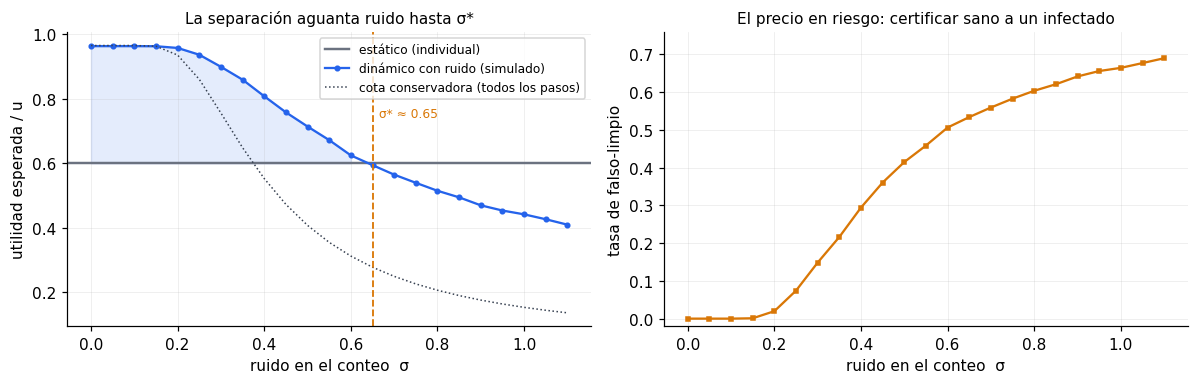

umbral de utilidad: σ* ≈ 0.65 (más de media persona de ruido antes de perder la ventaja)


In [9]:
# figura: la separación contra el ruido (izq) y el precio en riesgo (der)
sigmas = np.linspace(0.0, 1.1, 23)
util = [dinamico_ruidoso_mc(B, G, q, float(s), sims=12000, seed=2)[0] for s in sigmas]
falso = [dinamico_ruidoso_mc(B, G, q, float(s), sims=12000, seed=2)[1] for s in sigmas]
cota = [sin_ruido * (1 - eps_por_paso(float(s))) ** (logG + 1) for s in sigmas]
# umbral sigma*: donde la utilidad dinámica cruza el estático
sig_star = next((float(s) for s, m in zip(sigmas, util) if m < est), None)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.axhline(est, color=GRIS, lw=1.6, label='estático (individual)')
ax1.plot(sigmas, util, marker='o', ms=3, color=AZUL, label='dinámico con ruido (simulado)')
ax1.plot(sigmas, cota, ls=':', color=TINTA, lw=1, label='cota conservadora (todos los pasos)')
ax1.fill_between(sigmas, est, util, where=[u > est for u in util], color=AZUL, alpha=0.12)
if sig_star is not None:
    ax1.axvline(sig_star, color=AMBAR, ls='--', lw=1.2)
    ax1.annotate(f'σ* ≈ {sig_star:.2f}', (sig_star, est), textcoords='offset points',
                 xytext=(4, 30), fontsize=8, color=AMBAR)
ax1.set_xlabel('ruido en el conteo  σ'); ax1.set_ylabel('utilidad esperada / u')
ax1.set_title('La separación aguanta ruido hasta σ*', fontsize=10)
ax1.legend(fontsize=8, loc='upper right')

ax2.plot(sigmas, falso, marker='s', ms=3, color=AMBAR)
ax2.set_xlabel('ruido en el conteo  σ')
ax2.set_ylabel('tasa de falso-limpio')
ax2.set_title('El precio en riesgo: certificar sano a un infectado', fontsize=10)
ax2.set_ylim(-0.02, max(0.05, max(falso) * 1.1))
fig.tight_layout(); plt.show()
print(f'umbral de utilidad: σ* ≈ {sig_star:.2f} '
      f'(más de media persona de ruido antes de perder la ventaja)')

**Lectura.** La separación es robusta: la ventaja en utilidad sobrevive
hasta σ\* ≈ 0.65, más de media persona de ruido en el conteo. La razón es de
diseño —el esquema solo necesita un bit por paso, no el conteo fino—, y por eso
la cota conservadora (que exige acertar todos los pasos) queda muy por debajo de
la utilidad real: los errores a menudo se recuperan. Pero el ruido cobra un
segundo precio que la utilidad media esconde: el falso-limpio crece rápido —a
σ = 0.3 ya certifica a un infectado ~15% de las veces, aun cuando en media
sigue ganando—. Para tamizaje, ese es el error peligroso, y reconecta con el
objetivo de riesgo/CVaR de trabajo previo.

**Para discutir.** ¿El objetivo correcto bajo ruido es la utilidad media o
la utilidad *segura* (con el falso-limpio acotado)? Y la perilla que aparece
sola: con re-medición (volver a probar el mismo pool para bajar σ efectivo, la
política SPRT del modelo C), ¿se puede empujar σ\* hacia arriba y el
falso-limpio hacia abajo a la vez, o hay un trade-off duro entre cobertura y
precisión?

## 4. Verificación de la fibra

En la sesión anterior surgió la duda sobre la *fibra* —los perfiles consistentes
con los conteos observados—: ¿por qué son solo cinco, y no debería valer el
perfil de todos-infectados? La respuesta, verificada abajo: la fibra son los
perfiles consistentes con lo que se *midió*, y el conteo exacto es una
restricción brutal. Todos-infectados es un estado válido a priori, pero daría
conteo 3, no 1, así que la evidencia lo descarta.

In [10]:
A = {0, 1, 2}; Bp = {2, 3, 4}   # dos pruebas que se traslapan en la persona 2
fibra_conteo, fibra_binaria = [], []
for z in itertools.product((0, 1), repeat=5):
    inf = {i for i in range(5) if z[i]}
    cA, cB = len(inf & A), len(inf & Bp)
    if cA == 1 and cB == 1:   fibra_conteo.append(z)   # aumentado: conteo exacto = 1
    if cA >= 1 and cB >= 1:   fibra_binaria.append(z)  # clásico: 'positivo' = >=1
todos = (1, 1, 1, 1, 1)
print(f'perfiles posibles: 2^5 = {2**5}')
print(f'fibra con CONTEO exacto = 1 : {len(fibra_conteo)}  ->',
      [''.join(map(str, z)) for z in fibra_conteo])
print(f'fibra con test BINARIO (>=1): {len(fibra_binaria)}')
print(f'todos-infectados en la fibra de conteo?  {todos in fibra_conteo}  '
      f'(su conteo en A = {len(set(range(5)) & A)}, no 1)')
print(f'todos-infectados en la fibra binaria?    {todos in fibra_binaria}')
print()
print('La caída de 25 a 5 perfiles ES el valor de contar: el conteo exacto')
print('descarta 20 mundos que el bit binario deja en pie.')

perfiles posibles: 2^5 = 32
fibra con CONTEO exacto = 1 : 5  -> ['00100', '01001', '01010', '10001', '10010']
fibra con test BINARIO (>=1): 25
todos-infectados en la fibra de conteo?  False  (su conteo en A = 3, no 1)
todos-infectados en la fibra binaria?    True

La caída de 25 a 5 perfiles ES el valor de contar: el conteo exacto
descarta 20 mundos que el bit binario deja en pie.


## 5. El parámetro β: un lookahead barato

**Intuición.** El greedy miope elige en cada paso el pool que *limpia* más
ahora: maximiza $P(r=0)\cdot\sum u$. El beta-greedy le suma un bono de
información, $\beta\cdot(\text{ganancia de información})$, que lo empuja a
veces a probar un pool que limpia menos hoy pero *informa* mejor para el paso
siguiente. Es un proxy barato del lookahead: sin resolver el futuro, premia
mirar. Debería ayudar justo donde la miopía duele — la misma instancia del
notebook de árboles, donde el greedy abría con la persona más valiosa y perdía.

**Afirmación.** En esa instancia, subir β desplaza el pool de apertura del
greedy hacia el pool informativo que elige el óptimo, y recupera ~85% del hueco
greedy→óptimo. Pero es un hump: demasiado β se pasa de rosca y cae por debajo
del greedy plano.

In [11]:
import random
from augmented.solver import solve_optimal_dapts
from augmented.state_reward_greedy import (greedy_myopic_beta_expected_utility as beu,
                                           _beta_best_pool)
from augmented.core import mask_str

# misma instancia que el notebook de árboles (n=4, B=2, G=2, semilla 185)
rb = random.Random(185); nb_, Bb, Gb = 4, 2, 2
pb = [rb.uniform(0.15, 0.7) for _ in range(nb_)]
ub = [rb.uniform(1.0, 4.0) for _ in range(nb_)]
opt_b = solve_optimal_dapts(pb, ub, Bb, Gb)[0]
greedy_plano = beu(pb, ub, Bb, Gb, 0.0)                 # beta=0 == greedy miope

betas = [round(0.25 * k, 2) for k in range(0, 33)]      # 0..8
eus = [beu(pb, ub, Bb, Gb, b, 'entropy') for b in betas]
best_eu = max(eus); best_beta = betas[eus.index(best_eu)]

# autoverificación: beta>0 mejora al greedy plano y ninguna beta supera al óptimo
assert best_eu > greedy_plano + 1e-6, 'ningún beta ayuda en esta instancia'
assert best_eu <= opt_b + 1e-9, 'beta-greedy superó al óptimo (imposible)'
recuperado = (best_eu - greedy_plano) / (opt_b - greedy_plano)
print(f'óptimo={opt_b:.3f}  greedy plano (β=0)={greedy_plano:.3f}  '
      f'mejor β={best_beta} → EU={best_eu:.3f}')
print(f'β recupera {recuperado:.0%} del hueco greedy→óptimo')
for b in (0.0, 1.0, 3.0, 5.0):
    print(f'  β={b}: EU={beu(pb,ub,Bb,Gb,b,"entropy"):.3f}  '
          f'abre con {mask_str(_beta_best_pool(pb,ub,Gb,nb_,0,b,"entropy"), nb_)}')

óptimo=2.892  greedy plano (β=0)=2.679  mejor β=3.0 → EU=2.861
β recupera 85% del hueco greedy→óptimo
  β=0.0: EU=2.679  abre con {2}
  β=1.0: EU=2.810  abre con {2,3}
  β=3.0: EU=2.861  abre con {1,2}
  β=5.0: EU=2.665  abre con {1,2}


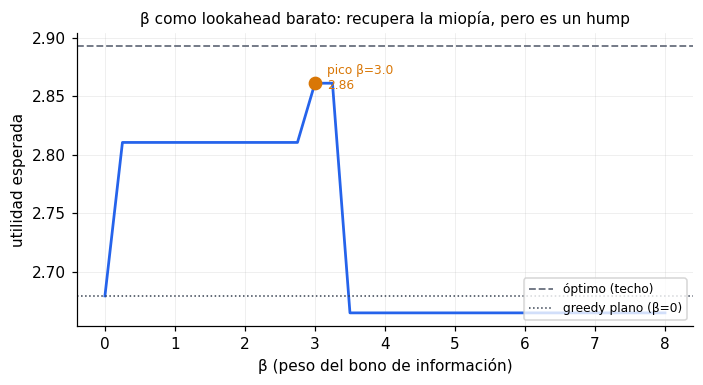

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(betas, eus, color=AZUL, lw=1.8)
ax.axhline(opt_b, color=GRIS, ls='--', lw=1.2, label='óptimo (techo)')
ax.axhline(greedy_plano, color=TINTA, ls=':', lw=1.0, label='greedy plano (β=0)')
ax.plot([best_beta], [best_eu], 'o', color=AMBAR, ms=8, zorder=3)
ax.annotate(f'pico β={best_beta}\n{best_eu:.2f}', (best_beta, best_eu),
            textcoords='offset points', xytext=(8, -4), fontsize=8, color=AMBAR)
ax.set_xlabel('β (peso del bono de información)')
ax.set_ylabel('utilidad esperada')
ax.set_title('β como lookahead barato: recupera la miopía, pero es un hump',
             fontsize=10)
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout(); plt.show()

**Lectura.** β funciona porque hace de lookahead de un paso: al crecer,
el pool de apertura salta de la persona más valiosa (miope) al par informativo
que el óptimo elige, y la utilidad sube casi hasta el techo. Pero es frágil en
dos sentidos. Es un hump: pasado el punto dulce, β sobre-pondera la información
y elige peor que el greedy plano. Y a prevalencia alta se neutraliza —cuando
casi nadie está sano, $P(r=0)$ colapsa y el bono de limpieza domina, así que
β deja de mover nada—. Es un proxy útil pero que hay que sintonizar.

**Para discutir.** β y la V̂ de la cota penalizada son la misma idea —un
proxy barato del valor a futuro— por dos caminos: β modifica la *política*, V̂
modifica la *cota*. ¿Es β un caso particular de la penalización? Y su punto
dulce (β≈3 aquí) con el hump: ¿la β correcta escala con el horizonte, como la
profundidad d(B) que buscamos para la V̂?

## 6. Encuadre para publicar

Del consejo de la sesión, cuatro reglas:

1. No mover dos variables a la vez. El beneficio tiene dos fuentes —ser dinámico
   y ser aumentado—; el ejemplo de la sección 1 mueve las dos juntas contra el
   mejor estático, que es la separación pedida. Para atribuir cuánto pone cada
   palanca, la comparación intermedia es el óptimo dinámico *binario* (donde la
   búsqueda de sanos por conteo no está disponible): queda como celda pendiente.
2. La dureza #P del posterior y la enumeración de la fibra van como trabajo
   futuro o apéndice, no en la línea principal.
3. Lo puramente dinámico (sin conteo) se refiere al trabajo previo del grupo.
4. La terna mandable es: ejemplo de separación + algoritmo eficiente en los
   regímenes tratables + evidencia empírica.

## 7. Cómo conecta con el certificado

El paper cercano y la dirección de fondo no compiten. El ejemplo de separación
mide *cuánto vale* el conteo en un caso resoluble; la línea del certificado mide
*cuánto de ese valor se puede reclamar y certificar con cómputo finito* cuando
el caso ya no es resoluble. El primero da el resultado publicable a corto plazo;
el segundo es el eje que le da coherencia a todo. La separación de la sección 1
es, de hecho, el extremo tratable del mismo objeto: donde la cota se puede
calcular exacta y la garantía es total.